## Predicting Acute Food Insecurity Risk in Kenyan Counties using Climate and Market Signals

**Author:** Data Alchemists

**Program:** Moringa School - Data Science Capstone Project

**Date:** June-July 2026


---

### Project Overview

Kenya's smallholder farmers and pastoralists face persistent food insecurity driven by rainfall failure and soaring staple food prices. This notebook builds a **binary classification model** that predicts whether a geographic zone in Kenya will reach **IPC Phase 3 (Crisis) or worse** in a given month using satellite-derived rainfall anomalies (CHIRPS) and WFP food price records as leading indicators.

The model is designed to support Kenya's **National Drought Management Authority (NDMA)** in issuing early warnings weeks before official IPC classifications are published.

---


### CRISP-DM Structure

This notebook follows the **CRISP-DM (Cross-Industry Standard Process for Data Mining)** framework:

| Phase | Section |
|---|---|
| Business Understanding | Phase 1 |
| Data Understanding | Phase 2 |
| Data Cleaning | Phase 3 |
| Data Preparation | Phase 4 |
| Modeling | Phase 5 |
| Evaluation | Phase 6 |

Each phase opens with a markdown cell explaining **WHY** the phase is necessary not just what is done.

---

### Datasets

| # | Dataset | Source | Rows | Role |
|---|---|---|---|---|
| 1 | FEWS NET IPC Classifications | HDX / FEWS NET | 27,694 | Target variable |
| 2 | CHIRPS Rainfall Indicators | HDX / WFP | 132,678 | Climate features |
| 3 | WFP Food Prices Kenya | HDX / WFP | 26,745 | Market features |

- **IPC/FEWS NET Phase Classifications** (`ipcphase.xlsx`): Household-level food insecurity 
  severity, published by FEWS NET (Famine Early Warning Systems Network). Each row is a 
  county/region assessed at a point in time and assigned an **IPC phase** from 1 (Minimal) 
  to 5 (Famine), covering both current status and forward-looking projections. This is our 
  **target variable** - what we're trying to predict.

- **CHIRPS Rainfall Anomalies** (`ken-rainfall-subnat-full.csv`): Satellite-derived rainfall 
  estimates at the sub-national level, reported roughly every 10 days (**dekadal**). Includes 
  raw rainfall (`rfh`), the long-term average for that same period (`rfh_avg`), and rainfall 
  as a **% of average** (`rfq`), the key drought/flood signal, since climate shocks are one 
  of the main drivers of acute food insecurity.

- **WFP Food Prices** (`wfp_food_prices_ken.csv`): Market price records collected by the 
  World Food Programme across Kenyan markets, reported **monthly**. Covers price and USD-
  normalized price for staple commodities (maize, beans, etc.) by market and region, rising 
  or volatile prices are another early signal of food insecurity risk.
  
---
### Domain Citations

1. Funk, C. et al. (2015). *The climate hazards infrared precipitation with stations.* Scientific Data, 2, 150066. Justifies CHIRPS choice and rfq interpretation  
2. FAO (2021). *IPC Technical Manual Version 3.1.* Justifies IPC Phase 3 as binary target threshold  
3. FEWS NET (2023). *Kenya Food Security Outlook, Oct 2022–Mar 2023.* Contextualises 2020–2023 crisis spikes





## PHASE 1: BUSINESS UNDERSTANDING

---

### 1.1 Background

Kenya's Arid and Semi-Arid Lands (ASALS) i.e Turkana, Marsabit, Mandera, Wajir, Garissa, Samburu and others are home to millions of pastrolists and smallholder farmers whose food security depends almost entirely on two fragile inputs: **rainfall** and **market access**. When rains fail, pasture and crops fail with them; when staple prices spike, the same households that lost their harvest can no longer afford to buy food to replace it. These two shocks compound each other, and together they are the dominant drivers of acute food insecurity in Kenya (FEWS NET, 2023).

Kenya's **National Draught Mangement Authority (NDMA)**, together with the Kenya Food Security Steering Group, currently relies on the **IPC (Intergrated Food Security Phase Classification)** system to declare when a county has crossed into **phase 3 (Crisis)** or worse. The problem is timing: IPC classification are produced through a structured, evidence-review process involving multiple agencies, and are only published **two to three times a year**.
Rainfall satellite data (CHIRPS) and WFP market price data, by contrast, are available continuously, rainfall every 10 days, prices every month. If the *relationship* between these leading indicators and the eventual IPC classification can be learned from historical data, it becomes possible to **flag deteriorating counties weeks to months before the next official IPC report is released.**

This capstone project treats that gap as a supervised machine learning problem.

## DATA UNDERSTANDING

##### Before touching a single value, we need to first know what we're working with:three datasets built by three different organisations, at three different spatial resolutions, on three differnt reporting schedules. The goal of this section is to answer four questions for each dataset i.e *what does a row look like,what are the dtypes,where are the gaps and what do the columns actually mean* so that every decision made later in Data Cleaning is evidence based rather than assumed.

In [2]:
#Importing Libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
!pip install openpyxl

In [4]:
#Loading the datasets
ipc_df = pd.read_excel('data/ipcphase.xlsx')
rainfall_df = pd.read_csv('data/ken-rainfall-subnat-full.csv')
food_df = pd.read_csv('data/wfp_food_prices_ken.csv')


In [5]:
# Checking the first 5 rows on ipc dataframe
ipc_df.head(20)

,row,source_organization,source_document,country,country_code,geographic_group,fewsnet_region,geographic_unit_full_name,geographic_unit_name,unit_type,...,specialization_type,dataseries_specialization_type,data_usage_policy,created,modified,status_changed,collection_status,collection_status_changed,collection_schedule,reporting_date
0,0,FEWS NET,"Food Security Outlook, Kenya",Kenya,KE,Eastern Africa,East Africa,"Aberdare Forest1, Murang'a, Central, Kenya",Aberdare Forest1,fsc_admin,...,/IPCPhase/,/IPCClassification/,Public,2020-11-25T18:47:21,2020-11-25T18:47:21,2020-11-25T18:53:10,Published,2021-01-05T21:16:32,Ad Hoc,2011-07-01
1,1,FEWS NET,"Food Security Outlook, Kenya",Kenya,KE,Eastern Africa,East Africa,"Aberdare Forest1, Murang'a, Central, Kenya",Aberdare Forest1,fsc_admin,...,/IPCPhase/,/IPCClassification/,Public,2020-11-25T18:47:21,2020-11-25T18:47:21,2020-11-25T18:53:10,Published,2021-01-05T21:16:32,Ad Hoc,2011-10-01
2,2,FEWS NET,"Food Security Outlook, Kenya",Kenya,KE,Eastern Africa,East Africa,"Aberdare Forest1, Murang'a, Central, Kenya",Aberdare Forest1,fsc_admin,...,/IPCPhase/,/IPCClassification/,Public,2020-11-25T18:47:21,2020-11-25T18:47:21,2020-11-25T18:53:10,Published,2021-01-05T21:16:32,Ad Hoc,2012-01-01
3,3,FEWS NET,"Food Security Outlook, Kenya",Kenya,KE,Eastern Africa,East Africa,"Aberdare Forest1, Murang'a, Central, Kenya",Aberdare Forest1,fsc_admin,...,/IPCPhase/,/IPCClassification/,Public,2020-11-25T18:47:21,2020-11-25T18:47:21,2020-11-25T18:53:10,Published,2021-01-05T21:16:32,Ad Hoc,2012-04-01
4,4,FEWS NET,"Food Security Outlook, Kenya",Kenya,KE,Eastern Africa,East Africa,"Aberdare Forest1, Murang'a, Central, Kenya",Aberdare Forest1,fsc_admin,...,/IPCPhase/,/IPCClassification/,Public,2020-11-25T18:47:21,2020-11-25T18:47:21,2020-11-25T18:53:10,Published,2021-01-05T21:16:31,Ad Hoc,2012-07-01
5,5,FEWS NET,"Food Security Outlook, Kenya",Kenya,KE,Eastern Africa,East Africa,"Aberdare Forest1, Murang'a, Central, Kenya",Aberdare Forest1,fsc_admin,...,/IPCPhase/,/IPCClassification/,Public,2020-11-25T18:47:21,2020-11-25T18:47:21,2020-11-25T18:53:10,Published,2021-01-05T21:16:31,Ad Hoc,2012-10-01
6,6,FEWS NET,"Food Security Outlook, Kenya",Kenya,KE,Eastern Africa,East Africa,"Aberdare Forest1, Murang'a, Central, Kenya",Aberdare Forest1,fsc_admin,...,/IPCPhase/,/IPCClassification/,Public,2020-11-25T18:47:21,2020-11-25T18:47:21,2020-11-25T18:53:10,Published,2021-01-05T21:16:31,Ad Hoc,2013-01-01
7,7,FEWS NET,"Food Security Outlook, Kenya",Kenya,KE,Eastern Africa,East Africa,"Aberdare Forest1, Murang'a, Central, Kenya",Aberdare Forest1,fsc_admin,...,/IPCPhase/,/IPCClassification/,Public,2020-11-25T18:47:21,2020-11-25T18:47:21,2020-11-25T18:53:10,Published,2021-01-05T21:16:31,Ad Hoc,2013-04-01
8,8,FEWS NET,"Food Security Outlook, Kenya",Kenya,KE,Eastern Africa,East Africa,"Aberdare Forest1, Murang'a, Central, Kenya",Aberdare Forest1,fsc_admin,...,/IPCPhase/,/IPCClassification/,Public,2020-11-25T18:47:21,2020-11-25T18:47:21,2020-11-25T18:53:10,Published,2021-01-05T21:16:30,Ad Hoc,2013-07-01
9,9,FEWS NET,"Food Security Outlook, Kenya",Kenya,KE,Eastern Africa,East Africa,"Aberdare Forest1, Murang'a, Central, Kenya",Aberdare Forest1,fsc_admin,...,/IPCPhase/,/IPCClassification/,Public,2020-11-25T18:47:21,2020-11-25T18:47:21,2020-11-25T18:53:10,Published,2021-01-05T21:16:30,Ad Hoc,2013-10-01


In [6]:
#Checking the first 5 rows on rainfall dataframe
rainfall_df.head()

,date,adm_level,adm_id,PCODE,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version
0,1981-01-01,1,51325,KE019,427.0,7.372365,15.759407,NaN,NaN,NaN,NaN,59.598840,NaN,NaN,final
1,1981-01-11,1,51325,KE019,427.0,4.325527,19.294770,NaN,NaN,NaN,NaN,38.384920,NaN,NaN,final
2,1981-01-21,1,51325,KE019,427.0,5.569087,16.265417,17.266980,51.319595,NaN,NaN,49.700817,39.536823,NaN,final
3,1981-02-01,1,51325,KE019,427.0,5.882904,12.719282,15.777517,48.279470,NaN,NaN,61.418427,38.997230,NaN,final
4,1981-02-11,1,51325,KE019,427.0,17.180328,18.768618,28.632318,47.753320,NaN,NaN,93.317700,63.753933,NaN,final


In [7]:
#Checking the first 5 rows on food dataframe
food_df.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,16.13,0.22
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47
3,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans (dry),262,90 KG,actual,Wholesale,KES,3246.00,45.15
4,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,17.00,0.24


# .head() observation

IPC - geagraphic_unit_ful_name is a single compound string like "Aberdare forest1, Muran'ga, Centarl, Kenya". it looks like a simple Location, County, Region, Country pattern but we shouldn't assume that holds for every row until we've checked.FEWS NET data is compiled from many sub-reports and administrative unit types.

Rainfall - There is no human-readable place name at all only PCODE (e.g KE019). Whatever County-level analysis we eventually want will require us to decode this codes ourselves.

Food Prices -  admin1(region), admin2(county-like field) are already separate, readable columns. The most analysis ready of the three datasets atleast on the surface.

## Checking the df info

.info() tells us row counts, dtypes and non-null counts in one shot. a fast way to catch dtype issues(eig dates stored as text) and missingness before we go column by column.

In [8]:
ipc_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27694 entries, 0 to 27693
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   row                             27694 non-null  int64  
 1   source_organization             27694 non-null  str    
 2   source_document                 27694 non-null  str    
 3   country                         27694 non-null  str    
 4   country_code                    27694 non-null  str    
 5   geographic_group                27694 non-null  str    
 6   fewsnet_region                  27694 non-null  str    
 7   geographic_unit_full_name       27694 non-null  str    
 8   geographic_unit_name            27694 non-null  str    
 9   unit_type                       27694 non-null  str    
 10  fnid                            27694 non-null  str    
 11  classification_scale            27694 non-null  str    
 12  scenario_name                   27694 non-n

In [9]:
rainfall_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 132678 entries, 0 to 132677
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   date       132678 non-null  str    
 1   adm_level  132678 non-null  int64  
 2   adm_id     132678 non-null  int64  
 3   PCODE      132678 non-null  str    
 4   n_pixels   132678 non-null  float64
 5   rfh        132678 non-null  float64
 6   rfh_avg    132678 non-null  float64
 7   r1h        132516 non-null  float64
 8   r1h_avg    132516 non-null  float64
 9   r3h        132030 non-null  float64
 10  r3h_avg    132030 non-null  float64
 11  rfq        132678 non-null  float64
 12  r1q        132516 non-null  float64
 13  r3q        132030 non-null  float64
 14  version    132678 non-null  str    
dtypes: float64(10), int64(2), str(3)
memory usage: 15.2 MB


In [10]:
food_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26745 entries, 0 to 26744
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          26745 non-null  str    
 1   admin1        26677 non-null  str    
 2   admin2        26677 non-null  str    
 3   market        26745 non-null  str    
 4   market_id     26745 non-null  int64  
 5   latitude      26677 non-null  float64
 6   longitude     26677 non-null  float64
 7   category      26745 non-null  str    
 8   commodity     26745 non-null  str    
 9   commodity_id  26745 non-null  int64  
 10  unit          26745 non-null  str    
 11  priceflag     26745 non-null  str    
 12  pricetype     26745 non-null  str    
 13  currency      26745 non-null  str    
 14  price         26745 non-null  float64
 15  usdprice      26745 non-null  float64
dtypes: float64(4), int64(2), str(10)
memory usage: 3.3 MB


**Insights:**

- **IPC** has 27,694 rows across a wide **42 columns** far more than we'll need for modelling. Many are FEWS NET database plumbing (`id`, `dataseries`, `datasourceorganization`, `created`, `modified`,....) rather than analytical fields. We keep them for now until we've inspected the dataset. Once we've identified which columns have analytical value, we'll remove the unnecessary ones during Data Cleaning.
- **Rainfall** is the largest table by far (132,678 rows) because it's reported at a **10-day (dekadal)** frequency going back to 1981, roughly 36 observations per location per year, versus IPC'S handful of classification per year.
- **Food Prices** (26,745 rows) already shows **68 non-null gaps** in `admin1`/`admin2`/`latitude`/`longtitude` right here in `.info()` which is worth tracking into the missing-values check below.
- All three date columns (`reporting_date`, `date`. `date`) are typed as `str`/`object`, not `datetime`. This has to be fixed before we can do any time based joining or feature extraction.

## Checking for missing values in the df

We now quantify the gaps `.info()` hinted at. The goal isn't just to count nulls but to figure out *why* each one is missing, because that determines whether we drop, impute, or leave it alone.

In [11]:
ipc_df.isnull().sum()

row                                   0
source_organization                   0
source_document                       0
country                               0
country_code                          0
geographic_group                      0
fewsnet_region                        0
geographic_unit_full_name             0
geographic_unit_name                  0
unit_type                             0
fnid                                  0
classification_scale                  0
scenario_name                         0
preference_rating                     0
is_allowing_for_assistance            0
projection_start                      0
projection_end                        0
status                                0
value                                 0
pct_phase3                        27694
pct_phase4                        27694
pct_phase5                        27694
description                           0
id                                    0
datacollectionperiod                  0


In [12]:
rainfall_df.isnull().sum()

date           0
adm_level      0
adm_id         0
PCODE          0
n_pixels       0
rfh            0
rfh_avg        0
r1h          162
r1h_avg      162
r3h          648
r3h_avg      648
rfq            0
r1q          162
r3q          648
version        0
dtype: int64

In [13]:
food_df.isnull().sum()

date             0
admin1          68
admin2          68
market           0
market_id        0
latitude        68
longitude       68
category         0
commodity        0
commodity_id     0
unit             0
priceflag        0
pricetype        0
currency         0
price            0
usdprice         0
dtype: int64

**Insights:**

- **IPC** - `pct_phase3`, `pct_phase4`, `pct_phase5` are **100% missing** (27,694 of 27,694 rows). This isn't a partial gap to impute since the columns carry zero information in this extract and are candidates to drop outright.
- **Rainfall** - `r1h`/`r1h_avg`/`r1q` are missing in 162 rows and `r3h_avg`/`r3q` in 648 rows. These are the 1-month and 3-month rolling rainfall aggregates; a plausible explanation is that they simply can't be computed at the very start of the 1981 time series before enough prior dekads exist, something to confirm rather than assume once we're deeper into cleaning.
- **Food Price** - exactly **68 rows** are missing `admin1`, `admin2`, `latitude`, and `longtitude` together, suggesting one specific market was entered without its region tags rather than random data loss. Worth identifying that market by name before deciding how to fix it.

## Checking for duplicates

Duplicate rows would silently double-count observations thus inflating the datasets i.e a county-month's apparent price volatility or IPC frequency. We check before any transformation, since duplicates introduced later (e.g. from a bad merge) are a different, later problem.

In [14]:
ipc_df.duplicated().sum()

np.int64(0)

In [15]:
rainfall_df.duplicated().sum()

np.int64(0)

In [16]:
food_df.duplicated().sum()

np.int64(0)

**Insight:** 

Zero exact-duplicate rows in all three raw datasets. That's a good sign for data lineage, but it doesn't guarantee there are no *logical* duplicates (e.g two rows for the same county-month with different values) although that kind of duplication can only be checked once we've defined our join keys, so we revisit this after standardising `county`/`date` in the Data cleaning section.

## Finding the number of rows and columns in each dataset


A simple `.shape` check, but useful to keep in mind as we plan the eventual merge: three tables of very different sizes and structures have to end up aligned on the same county + month keys.

In [17]:
ipc_df.shape

(27694, 42)

In [18]:
rainfall_df.shape

(132678, 15)

In [19]:
food_df.shape

(26745, 16)

**Insight:** rainfall (132,678 rows) outnumbers food prices (26,745) by 5x and IPC (27,694) by nearly the same margin, almost entirely a function of reporting frequency (dekadal vs. monthly vs. quarterly), not geographic coverage. In fact, as we'll see later, rainfall's *row count* is large despite covering far *fewer counties* than the other two datasets. A remindre that row count alone doesn't tell us about geographic breadth.

## Checking the column names for each dataset

Column names tell us how each source encodes geography and time, the two keys we'll eventually need to join on.

In [20]:
ipc_df.columns

Index(['row', 'source_organization', 'source_document', 'country',
       'country_code', 'geographic_group', 'fewsnet_region',
       'geographic_unit_full_name', 'geographic_unit_name', 'unit_type',
       'fnid', 'classification_scale', 'scenario_name', 'preference_rating',
       'is_allowing_for_assistance', 'projection_start', 'projection_end',
       'status', 'value', 'pct_phase3', 'pct_phase4', 'pct_phase5',
       'description', 'id', 'datacollectionperiod', 'datacollection',
       'scenario', 'geographic_unit', 'datasourceorganization',
       'datasourcedocument', 'dataseries', 'dataseries_name',
       'specialization_type', 'dataseries_specialization_type',
       'data_usage_policy', 'created', 'modified', 'status_changed',
       'collection_status', 'collection_status_changed', 'collection_schedule',
       'reporting_date'],
      dtype='str')

In [21]:
rainfall_df.columns

Index(['date', 'adm_level', 'adm_id', 'PCODE', 'n_pixels', 'rfh', 'rfh_avg',
       'r1h', 'r1h_avg', 'r3h', 'r3h_avg', 'rfq', 'r1q', 'r3q', 'version'],
      dtype='str')

In [22]:
food_df.columns

Index(['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude',
       'longitude', 'category', 'commodity', 'commodity_id', 'unit',
       'priceflag', 'pricetype', 'currency', 'price', 'usdprice'],
      dtype='str')

**Insight:**

**Three different geography schemes, one join to make:** IPC identifies place via `geographic_unit_full_name` (a compound string), rainfall via `PCODE` (an opaque code), and food prices via `admin1`/`admin2` (readable names). None of these three use the same convention, and none is guranteed to use Kenyan's current 47-county boundaries. Harmonising this is the central challenge of the Data Cleaning phase that follows, everything else (missing values, duplicates, dtypes) is comparatively mechanical

---
## VISUALIZING DISTRIBUTIONS OF THE DATASETS

Numbers alone ((`.info()`, `.isnull()`, `.duplicated()`) tell us that something is off, but not how the data is shaped.

Plots show us if values are skewed, if categories balanced, and where exactly the gaps are concentrated.

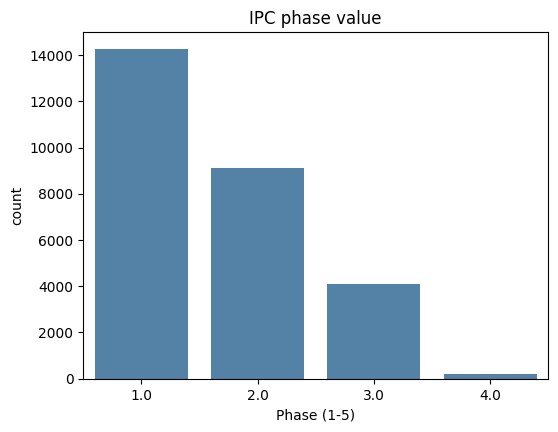

In [23]:
# IPC phase value distribution
plt.figure(figsize=(6, 4.5))
sns.countplot(x="value", data=ipc_df, color="steelblue")
plt.title("IPC phase value")
plt.xlabel("Phase (1-5)")
plt.ylabel("count")
plt.show()

**Insight:**

The distribution of IPC phases is highly imbalanced, with over half of all observations belonging to **Phase 1 (Minimal)**, while **Phase 4 (Emergency)** represents less than 1% of the dataset and **Phase 5 (Famine)** is completely absent. This indicates that severe food insecurity events are relatively rare compared to lower-severity conditions.

For modelling, this imbalance is important because a classifier trained on the raw data could become biased toward predicting the majority class, resulting in high overall accuracy but poor detection of crisis situations. Since the project aims to identify counties at risk of acute food insecurity, techniques such as binary classification (Phase 3+ vs. below Phase 3), class weighting, or resampling will need to be considered during model development.

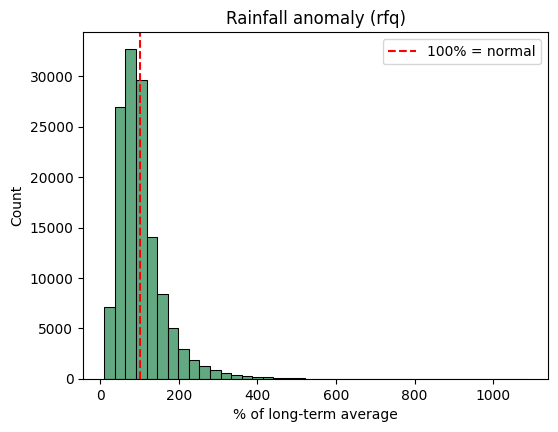

In [24]:
# Rainfall anomaly (rfq) distribution
plt.figure(figsize=(6, 4.5))
sns.histplot(rainfall_df["rfq"], bins=40, color="seagreen")
plt.axvline(100, color="red", linestyle="--", label="100% = normal")
plt.title("Rainfall anomaly (rfq)")
plt.xlabel("% of long-term average")
plt.legend()
plt.show()

**Insight:**

Most rainfall observations are clustered close to the long-term average (around 100%), indicating that normal rainfall conditions occur most frequently. However, the distribution is positively skewed, with a relatively small number of observations representing extremely wet periods.

This pattern suggests that while exceptional rainfall events do occur, they are much less common than normal or below-average rainfall conditions. Since drought is a major driver of food insecurity in Kenya, rainfall deficits are expected to be more informative than unusually wet periods when predicting IPC Phase 3 or worse. The skewness also indicates that rainfall features may benefit from scaling or aggregation during data preparation to reduce the influence of extreme values.

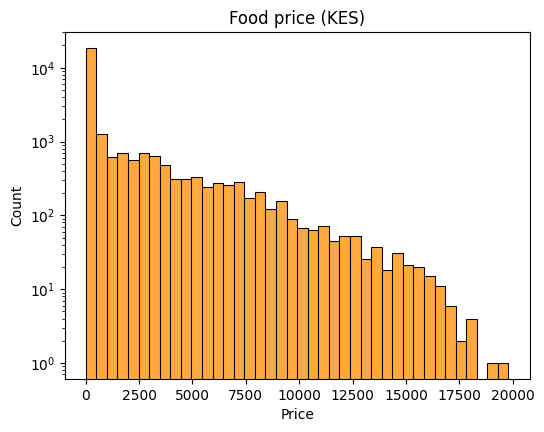

In [25]:
# Food price distribution
plt.figure(figsize=(6, 4.5))
sns.histplot(food_df["price"], bins=40, color="darkorange")
plt.yscale("log")
plt.title("Food price (KES)")
plt.xlabel("Price")
plt.show()

**Insight:**

Food prices exhibit a strongly right-skewed distribution, with most observations concentrated at relatively low prices and a small number of very expensive commodities creating a long upper tail. The large difference between the mean and median confirms that extreme values are influencing the overall distribution.

These high prices are likely due to differences in commodity type, package size, or measurement units rather than data entry errors. Therefore, the observed skewness reflects genuine market variation rather than outliers that should be removed. During data preparation, food prices should be analysed within commodity groups and may require a logarithmic transformation or normalization to improve their suitability for machine learning models.

---

# DATA CLEANING

Data understanding surfaced four concrete problems to solve before this data is usable together:

1. Date columns are stored as text, not `datetime`.
2. `pct_phase3/4/5` in IPC are 100% empty.
3. 68 food price rows are missing region/coordinate fields, tied to a single market.
4. Geography is encoded three different ways across the three datasets, and none is confirmed to match Kenya's 47 counties.

## Dropping Unnecessary IPC Columns

The IPC dataset originally contains 42 columns, many of which are administrative metadata used internally by FEWS NET rather than variables that describe food insecurity itself. Examples include record identifiers, database timestamps, source tracking information, and collection management fields.

Additionally, the columns `pct_phase3`, `pct_phase4`, and `pct_phase5` contain 100% missing values, meaning they provide no usable information for analysis or modelling.

Removing these columns reduces unnecessary complexity, improves readability, and ensures that subsequent analysis focuses only on variables that contribute to understanding or predicting food insecurity.

In [26]:
# Dropping the 100%-empty pct_phase columns and FEWS NET database plumbing columns
drop_cols = [
    'row', 'source_organization', 'source_document', 'country', 'country_code',
    'geographic_group', 'geographic_unit_name', 'fnid', 'pct_phase3', 'pct_phase4',
    'pct_phase5', 'description', 'id', 'datacollectionperiod', 'datacollection',
    'scenario', 'geographic_unit', 'datasourceorganization', 'datasourcedocument',
    'dataseries', 'dataseries_name', 'specialization_type', 'dataseries_specialization_type',
    'data_usage_policy', 'created', 'modified', 'status_changed', 'collection_status',
    'collection_status_changed', 'collection_schedule'
]

ipc_df = ipc_df.drop(columns=drop_cols)
ipc_df.columns

Index(['fewsnet_region', 'geographic_unit_full_name', 'unit_type',
       'classification_scale', 'scenario_name', 'preference_rating',
       'is_allowing_for_assistance', 'projection_start', 'projection_end',
       'status', 'value', 'reporting_date'],
      dtype='str')

**Insight:** IPC drops from 42 columns to 12. What's left is exactly what we need: the geography field, `unit_type` and `classification_scale` (needed to correctly parse geography and distinguish current vs. projected assessments), `scenario_name`, `preference_rating`, `status`, the reporting dates, and `value`, our IPC phase target.

## Standardizing Column Names

Before combining datasets, it is important that all column names follow a consistent naming convention. Different datasets often use different capitalization, spacing, or formatting styles, making the code harder to write and maintain.

We convert every column name to lowercase, remove unnecessary spaces, and replace spaces with underscores. This creates a consistent structure across all datasets, reduces the likelihood of typing errors, and makes later processing steps much easier.

In [27]:
# Standardizing the column names
# Ensuring that all columns are in lowercase
ipc_df.columns = ipc_df.columns.str.lower().str.strip().str.replace(" ", "_")
rainfall_df.columns = rainfall_df.columns.str.lower().str.strip().str.replace(" ", "_")
food_df.columns = food_df.columns.str.lower().str.strip().str.replace(" ", "_")

In [28]:
# Checking our standardized columns
ipc_df.columns

Index(['fewsnet_region', 'geographic_unit_full_name', 'unit_type',
       'classification_scale', 'scenario_name', 'preference_rating',
       'is_allowing_for_assistance', 'projection_start', 'projection_end',
       'status', 'value', 'reporting_date'],
      dtype='str')

In [29]:
rainfall_df.columns

Index(['date', 'adm_level', 'adm_id', 'pcode', 'n_pixels', 'rfh', 'rfh_avg',
       'r1h', 'r1h_avg', 'r3h', 'r3h_avg', 'rfq', 'r1q', 'r3q', 'version'],
      dtype='str')

In [30]:
food_df.columns

Index(['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude',
       'longitude', 'category', 'commodity', 'commodity_id', 'unit',
       'priceflag', 'pricetype', 'currency', 'price', 'usdprice'],
      dtype='str')

## Converting Date Columns

The date columns are initially stored as text (`object`) rather than actual dates. While they may look like dates to us, Python cannot perform date-based operations until they are converted into the `datetime` format.

Converting these columns allows us to perform time-based analysis such as extracting months and years, sorting chronologically, calculating time differences, and aligning observations across the three datasets.

In [31]:
# Date handling
from datetime import datetime

# Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer


In [32]:
# Changing the date columns to datetime
ipc_df['reporting_date'] = pd.to_datetime(ipc_df['reporting_date'])
rainfall_df['date'] = pd.to_datetime(rainfall_df['date'])
food_df['date'] = pd.to_datetime(food_df['date'])

In [33]:
print("IPC:")
print(ipc_df['reporting_date'].head())

print("\nRAINFALL:")
print(rainfall_df['date'].head())

print("\nFOOD:")
print(food_df['date'].head())

IPC:
0   2011-07-01
1   2011-10-01
2   2012-01-01
3   2012-04-01
4   2012-07-01
Name: reporting_date, dtype: datetime64[us]

RAINFALL:
0   1981-01-01
1   1981-01-11
2   1981-01-21
3   1981-02-01
4   1981-02-11
Name: date, dtype: datetime64[us]

FOOD:
0   2006-01-15
1   2006-01-15
2   2006-01-15
3   2006-01-15
4   2006-01-15
Name: date, dtype: datetime64[us]


## Extracting Time Features

Although each dataset contains a complete date, the three sources are reported at different frequencies. Rainfall is recorded every ten days, food prices are collected monthly, and IPC assessments are conducted only a few times each year.

Extracting the `year` and `month` creates common temporal features that can later be used to aggregate and merge the datasets. Using these shared time keys is more reliable than attempting to match exact dates across datasets collected on different schedules.

In [34]:
# Extracting Time Features
# IPC
ipc_df['reporting_date'] = pd.to_datetime(ipc_df['reporting_date'])

ipc_df['year'] = ipc_df['reporting_date'].dt.year
ipc_df['month'] = ipc_df['reporting_date'].dt.month

# RAINFALL
rainfall_df['date'] = pd.to_datetime(rainfall_df['date'])

rainfall_df['year'] = rainfall_df['date'].dt.year
rainfall_df['month'] = rainfall_df['date'].dt.month

# FOOD
food_df['date'] = pd.to_datetime(food_df['date'])
food_df['year'] = food_df['date'].dt.year
food_df['month'] = food_df['date'].dt.month

## Creating a Standard County Reference

The three datasets describe geography using different naming systems. Some use official county names, others use historical district names, sub-counties, or administrative codes.

To ensure that all datasets refer to locations consistently, we first define Kenya's 47 official counties. This serves as the standard geographic reference against which every location in the datasets will be compared and mapped.



In [35]:
# The 47 official Kenyan counties, in their constitutional numbering order (001-047).
# This order also doubles as the PCODE lookup for the rainfall dataset later.
official_counties = [
    "Mombasa", "Kwale", "Kilifi", "Tana River", "Lamu", "Taita-Taveta", "Garissa", "Wajir",
    "Mandera", "Marsabit", "Isiolo", "Meru", "Tharaka-Nithi", "Embu", "Kitui", "Machakos",
    "Makueni", "Nyandarua", "Nyeri", "Kirinyaga", "Murang'a", "Kiambu", "Turkana", "West Pokot",
    "Samburu", "Trans-Nzoia", "Uasin Gishu", "Elgeyo-Marakwet", "Nandi", "Baringo", "Laikipia",
    "Nakuru", "Narok", "Kajiado", "Kericho", "Bomet", "Kakamega", "Vihiga", "Bungoma", "Busia",
    "Siaya", "Kisumu", "Homa Bay", "Migori", "Kisii", "Nyamira", "Nairobi"
]

## Creating County Aliases

Historical datasets often contain outdated district names, sub-counties, towns, or alternative spellings instead of the current official county names.

A county alias dictionary is created to translate these alternative names into the official county names. This ensures that different names referring to the same geographic area are standardized before the datasets are merged.

In [36]:
# Aliases: pre-2010 districts and sub-county/town names -> the modern county they belong to
county_aliases = {
    "bondo": "Siaya", "buret": "Kericho", "butere/mumias": "Kakamega",
    "central kisii": "Kisii", "elgeyo marakwet": "Elgeyo-Marakwet", "gucha": "Kisii",
    "ijara": "Garissa", "keiyo": "Elgeyo-Marakwet", "koibatek": "Baringo",
    "kuria": "Migori", "lugari": "Kakamega", "maragua": "Murang'a",
    "marakwet": "Elgeyo-Marakwet", "malindi": "Kilifi", "mbeere": "Embu",
    "meru central": "Meru", "meru north": "Meru", "meru south": "Meru",
    "moyale": "Marsabit", "mt elgon": "Bungoma", "mt. elgon": "Bungoma",
    "mwingi": "Kitui", "nyando": "Kisumu", "rachuonyo": "Homa Bay", "suba": "Homa Bay",
    "teso": "Busia", "tharaka": "Tharaka-Nithi", "tharaka nithi": "Tharaka-Nithi",
    "thika": "Kiambu", "trans mara": "Narok", "trans nzoia": "Trans-Nzoia",
    "taita taveta": "Taita-Taveta",
}

## Creating a County Standardization Function

Rather than repeating the same cleaning code throughout the notebook, a reusable function is created to standardize county names.

The function checks whether a location exists in the county alias dictionary and returns the corresponding official county name. Unknown or missing locations are returned as missing values (`NaN`) so they can be investigated later instead of being incorrectly assigned.

In [37]:
# Every official county also maps to itself, so already-correct names pass through unchanged
for name in official_counties:
    county_aliases.setdefault(name.lower(), name)

def standardize_county(raw_name):
    """Map any raw geography string to one of the 47 official county names, or NaN if unknown/blank."""
    if pd.isna(raw_name) or str(raw_name).strip() == '':
        return np.nan
    return county_aliases.get(str(raw_name).strip().lower(), np.nan)

**Insight:** This dict was built by first running the extraction below with no crosswalk, inspecting every value that *didn't* land in the official 47, and deciding case-by-case whether it was an old district (map it), a sub-county/town (map it to its parent county), or genuinely missing (leave as NaN, handled per dataset below).

## Extracting County Names from the IPC Dataset

The IPC dataset stores geographic information as a single text field rather than a dedicated county column. Furthermore, the format differs depending on the type of administrative unit being described.

A custom extraction function identifies the correct part of the location string for each unit type before standardizing it using the county reference dictionary. This produces a single, consistent county column that can later be used for merging with the rainfall and food price datasets.

In [38]:
# Extracting the raw geography token based on unit_type, then standardizing it against
# the shared crosswalk built above
def extract_ipc_county_raw(row):
    parts = [p.strip() for p in str(row['geographic_unit_full_name']).split(',')]
    unit_type = row['unit_type']
    if unit_type == 'idp_camp':
        camp_lookup = {'Dadaab Refugee Camp': 'Garissa', 'Kakuma Refugee Camp': 'Turkana'}
        return camp_lookup.get(parts[0])
    elif unit_type == 'fsc_admin':
        return parts[-3] if len(parts) >= 3 else None
    elif unit_type == 'fsc_admin_lhz':
        return parts[-2] if len(parts) >= 2 else None
    return None

ipc_df['county'] = ipc_df.apply(extract_ipc_county_raw, axis=1).apply(standardize_county)

print("Unmapped rows:", ipc_df['county'].isnull().sum(), "of", len(ipc_df))
print("Unique counties:", ipc_df['county'].nunique())
ipc_df[['geographic_unit_full_name', 'unit_type', 'county']].head()

Unmapped rows: 0 of 27694
Unique counties: 47


,geographic_unit_full_name,unit_type,county
0,"Aberdare Forest1, Murang'a, Central, Kenya",fsc_admin,Murang'a
1,"Aberdare Forest1, Murang'a, Central, Kenya",fsc_admin,Murang'a
2,"Aberdare Forest1, Murang'a, Central, Kenya",fsc_admin,Murang'a
3,"Aberdare Forest1, Murang'a, Central, Kenya",fsc_admin,Murang'a
4,"Aberdare Forest1, Murang'a, Central, Kenya",fsc_admin,Murang'a


**Insight:** all 27,694 rows now resolve to exactly one of Kenya's 47 counties - zero unmapped. Compare that to the original approach, which produced 448 distinct "counties" by pulling sub-county and livelihood-zone names for the `fsc_admin_lhz` rows (65% of the dataset).

## Mapping Rainfall PCODEs to Counties

Unlike the other datasets, the rainfall dataset identifies locations using administrative PCODEs instead of county names.

A lookup table is created to translate each PCODE into its corresponding official county. For sub-county PCODEs, only the county portion of the code is used, ensuring that every rainfall observation is assigned to one of Kenya's 47 counties.

In [39]:
# Reusing official_counties' order to build the PCODE -> county lookup (KE001 = Mombasa, ... KE047 = Nairobi)
pcode_to_county = {f"KE{str(i).zfill(3)}": name for i, name in enumerate(official_counties, start=1)}

# adm_level 2 PCODEs are longer (e.g. KE001003); the first 5 characters are the parent county code
rainfall_df['county'] = rainfall_df['pcode'].str[:5].map(pcode_to_county)

print("Unmapped rows:", rainfall_df['county'].isnull().sum(), "of", len(rainfall_df))
print("Unique counties:", rainfall_df['county'].nunique())
rainfall_df[['pcode', 'adm_level', 'county']].head()

Unmapped rows: 0 of 132678
Unique counties: 47


,pcode,adm_level,county
0,KE019,1,Nyeri
1,KE019,1,Nyeri
2,KE019,1,Nyeri
3,KE019,1,Nyeri
4,KE019,1,Nyeri


**Insight:** all 132,678 rows map cleanly to all 47 counties with zero unmapped rows, confirming the PCODE scheme follows the same official numbering used everywhere else in Kenyan government/humanitarian data.

## Standardizing County Names in the Food Price Dataset

The food price dataset already contains readable county names, but some rows use alternative names or contain missing county values.

The county standardization function is applied to ensure consistency with the other datasets. Rows belonging to the Hola market are manually assigned to Tana River County because the county information is contained within the market name even though the county field is missing.

In [40]:
food_df = food_df.rename(columns={'admin2': 'county_raw'})
food_df['county'] = food_df['county_raw'].apply(standardize_county)

# Backfill the 68 rows tied to the Hola (Tana River) market - the county is in the market name
food_df.loc[food_df['market'] == 'Hola (Tana River)', 'county'] = 'Tana River'

food_df = food_df.drop(columns=['county_raw'])

print("Unmapped rows:", food_df['county'].isnull().sum(), "of", len(food_df))
print("Unique counties:", food_df['county'].nunique())
sorted(food_df['county'].unique())

Unmapped rows: 0 of 26745
Unique counties: 24


['Baringo',
 'Garissa',
 'Isiolo',
 'Kajiado',
 'Kilifi',
 'Kisumu',
 'Kitui',
 'Kwale',
 'Machakos',
 'Makueni',
 'Mandera',
 'Marsabit',
 'Meru',
 'Mombasa',
 'Nairobi',
 'Nakuru',
 'Nyeri',
 'Samburu',
 'Taita-Taveta',
 'Tana River',
 'Turkana',
 'Uasin Gishu',
 'Wajir',
 'West Pokot']

**Insight:** zero unmapped rows left, and food prices cover 24 of the 47 counties - fewer than IPC or rainfall, since WFP only tracks prices at specific markets rather than every county. That's expected and just means the eventual merge will have food-price gaps for counties with no monitored market, not a cleaning bug.

## Validating County Standardization

After standardizing the county names in all three datasets, a final validation step is performed to ensure that every county belongs to Kenya's official list of 47 counties.

This quality check helps identify spelling mistakes, unmapped aliases, or unexpected location names before the datasets are merged. Detecting these issues early prevents rows from being lost during the merge process.

In [41]:
for name, df in {"IPC": ipc_df, "Rainfall": rainfall_df, "Food Prices": food_df}.items():
    counties = set(df['county'].dropna().unique())
    not_official = counties - set(official_counties)
    print(f"{name}: {len(counties)} counties, {len(not_official)} not in the official 47 -> {not_official}")

IPC: 47 counties, 0 not in the official 47 -> set()
Rainfall: 47 counties, 0 not in the official 47 -> set()
Food Prices: 24 counties, 0 not in the official 47 -> set()


**Insight:** County standardization was successful across all three datasets. IPC and rainfall now cover all 47 official Kenyan counties, while the food price dataset covers only 24 counties because WFP collects market data in selected locations rather than nationwide. Importantly, no county names fall outside the official 47-county reference (`set()` is empty for all datasets), confirming that spelling differences, aliases, sub-counties, and administrative codes have been correctly mapped. This ensures that county-based merges can be performed reliably without losing records due to geographic naming inconsistencies.

# EXPLORATORY DATA ANALYSIS (EDA)

Data cleaning gave us three trustworthy, county-tagged tables. That is necessary but not sufficient: `.isnull()` and `.duplicated()` tell us the data is *clean*, they say nothing about whether it is *predictive*. Before any modelling decision is made, we need to see the actual relationship between the leading indicators (rainfall, prices) and the target (IPC phase) at the same county-month grain the model will eventually use. This section:

1. Builds the binary target (`crises = IPC phase 3+`) and checks how it is distributed across `scenario_name`/`status`, since the IPC dataset mixes *current* and *projected* classifications.
2. Aggregate rainfall and food prices to a common **county-month** grain so they can be compared against the target.
3. Merges the three sources and quantifies exactly how much data survives the join (this is where the earlier insight where food prices cover only 24/47 counties starts to bite).
4. Looks at the target over time, by county, and against each leading indicator, to confirm (or challenge) the domain assumption that rainfall deficits and price spikes precedes crises.

## 1. Building the Target Variable

`ipc_df['value']` holds the IPC phase (1-5). The business objective in phase 1 defined the target as **binary**: phase 3 or worse = 1 (crises), phase 1-2 = 0. Before creating it, we check `scenario_name` and `status`, because FEWS NET publishes both a **current** classification and **foward-looking projections** for the same geography therefore, training on projection rows would leak future assumptions into a model meant to predict the future.

In [43]:
# Inspect the scenario/status fields that distinguish "current" from "projected" classifications
print("scenario_name value counts:")
print(ipc_df['scenario_name'].value_counts())
print("\nstatus value counts:")
print(ipc_df['status'].value_counts())

scenario_name value counts:
scenario_name
Current Situation    27694
Name: count, dtype: int64

status value counts:
status
Collected    27694
Name: count, dtype: int64


**Insight:** 
In this extract, `scenario_name` is **100% "current situation"** (27,694 of 27,694 rows) and `status` is 100% "collected". FEWS NET's foward-looking *projection* scenarios simply aren't present in this download. This is good news for the leakage risk raised in Business Understanding: there is nothing to accidentally filter out here, but it also means the "current situation" filter below is a documentation/safety steps for future data pulls rather than something that changes today's row count.